# Comparison

This chapter covers joint distributions which are an essential tool for working with distributions of more than one variable. 

Many useful operations can be expressed as the 'outer product' of two sequences or another kind of 'outer' operation. 

In [1]:
# suppose you have two sequences

x = [1, 3, 5]
y = [2, 4]

# the outer product of these sequences is an array that contains the product  of each pair of their values

In [2]:
import numpy as np

X, Y = np.meshgrid(x, y)

In [5]:
X

array([[1, 3, 5],
       [1, 3, 5]])

In [6]:
Y

array([[2, 2, 2],
       [4, 4, 4]])

In [7]:
X * Y

array([[ 2,  6, 10],
       [ 4, 12, 20]])

In [8]:
import pandas as pd

df = pd.DataFrame(X * Y, columns = x, index = y)
df

,1,3,5
2,2,6,10
4,4,12,20


In [9]:
X > Y

array([[False,  True,  True],
       [False, False,  True]])

## How Tall Is A?

What if we chose two random adult males in the US, A and B. If we see that A is taller than B, how tall is A?

To answer this question:

1. We'll use background information about male height in the US to make a prior distribution.
2. We'll construct a joint prior distribution of height for A and B.
3. We'll update the prior with the information that A is taller.
4. From the joint posterior distrubtion, we'll extract the posterior distribution of height for A. 

In the US, the average height of adult males is 178 cm and the standard deviation is 7.7 cm. The distribution is not exactly normal but pretty close. So, we'll use that as a prior distribution for A and B. 

In [10]:
mean = 178
qs = np.arange(mean-24, mean+24, 0.5)

In [11]:
from scipy.stats import norm

std = 7.7
ps = norm(mean, std).pdf(qs)

In [13]:
from empiricaldist import Pmf

prior = Pmf(ps, qs)
prior.normalize()

np.float64(1.9963309462450582)

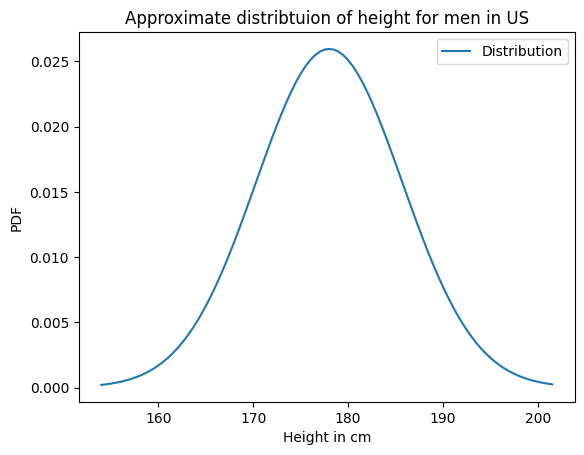

In [18]:
import matplotlib.pyplot as plt

prior.plot(label = 'Distribution')
plt.xlabel('Height in cm')
plt.ylabel('PDF')
plt.title('Approximate distribtuion of height for men in US')
plt.legend()
plt.show()

## Joint Distribution

The next step is to construct a distribution that represents the probability of every pair of heights, a joint distribution. The elements of this distribution are:

$$ P(A_x \; and \; B_y) $$

Which his the probability that A is x cm tall and by is y cm tall for all values of x and y. 

A all we know is that A and B are adult male residents of the US. Knowing the height of A tells us nothing about the height of B. In this case, we compute the joing probabilities like this:

$$ P(A_x \; and \; B_y) = P(A_x) \; P(B_y) $$

Each joing probability of the probability is the product of one of the elements from the distribution of x and one from y. So, if we have Pmf objects that represent the distributions of height for A and B, we can compute the joint distribution by computing the outer product of the probabilities in each Pmf. 

In [20]:
def make_joint(pmf1, pmf2):
    """ Compute the outer product of two Pmfs"""
    X, Y = np.meshgrid(pmf1, pmf2)
    return pd.DataFrame(X * Y, columns = pmf1.qs, index = pmf2.qs)

In [21]:
# prior distributions for A and B are the same. So we compute the joint prior like this:

joint = make_joint(prior, prior)
joint.shape

(96, 96)

In [22]:
# if the prior is normalized, the joint prior is also normalized

joint.to_numpy().sum()

np.float64(1.0)

## Visualizing the Joint Distribution

In [34]:
from utils import decorate

def plot_joint(joint, cmap = 'Blues'):
    """ Plot a joint distribution with a color mesh """
    vmax = joint.to_numpy().max() * 1.1
    plt.pcolormesh(joint.columns, joint.index, joint, 
                    cmap = cmap, 
                    vmax = vmax, 
                    shading = 'nearest')
    plt.colorbar()
    decorate(xlabel = 'A height in cm', 
            ylabel = 'B height in cm')


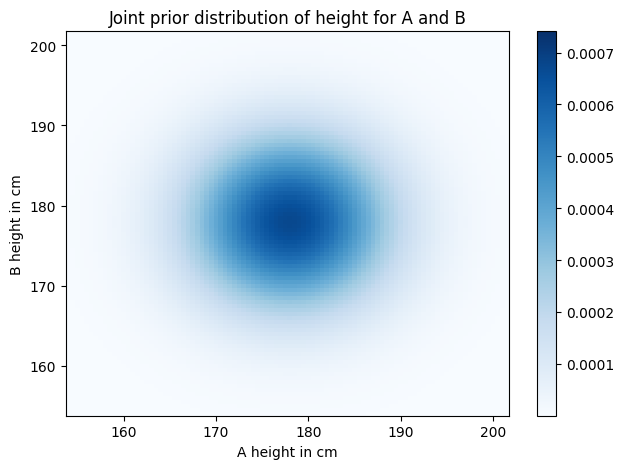

In [36]:
plot_joint(joint)
decorate(title='Joint prior distribution of height for A and B')

As you might expect, the probability is darkets near the mean and decreases from there. 

You can also visualize it with contours:

In [38]:
def plot_contour(joint):
    """ Plot a joint distribution with a contour """
    plt.contour(joint.columns, joint.index, joint, linewidths = 2)
    decorate(xlabel= 'A height in cm', ylabel = 'B height in cm')

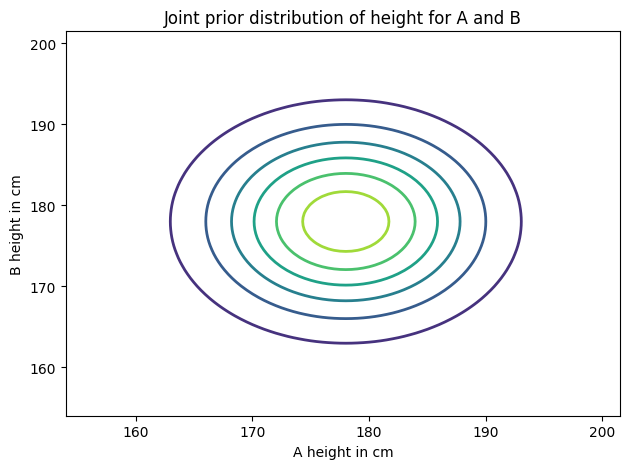

In [40]:
plot_contour(joint)
decorate(title='Joint prior distribution of height for A and B')

## Likelihood

Now that we have a joint prior distribution, we can update it with the data: A is taller than B. 

Each element in the joint distribution represents a hypothesis about the heights of A and B. To compute the likelihood of each pair of quantities, we can extract the column names and rows liek this:

In [41]:
x = joint.columns
y = joint.index

# use them to compute mesh grid

X, Y = np.meshgrid(x, y)

X contains copies of the quantities in x that are possible for A. Y contains copies of possible quantities for B. If we compare X and Y, the result is a Boolean array:

In [44]:
A_taller = (X > Y)
A_taller.dtype

dtype('bool')

In [45]:
# compute likelihoods using np.where to make array with 1 where A_taller is true and 0 elsewhere

a = np.where(A_taller, 1, 0)

# put it in a dataframe to visualize

likelihood = pd.DataFrame(a, index = x, columns = y)

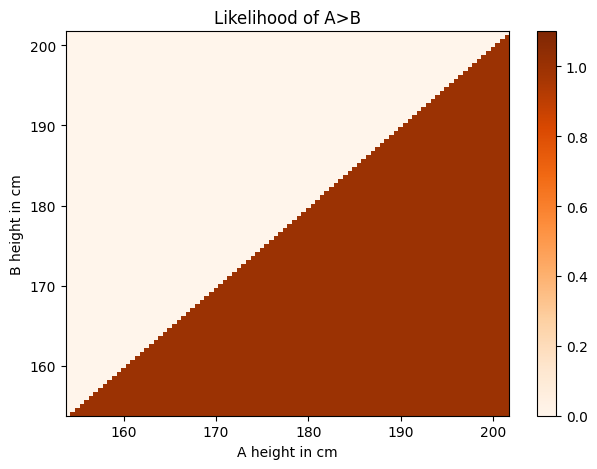

In [46]:
plot_joint(likelihood, cmap='Oranges')
decorate(title='Likelihood of A>B')

## Update

Now we have a prior, a likelihood, and we are ready for the update. 

In [47]:
posterior = joint * likelihood

In [48]:
def normalize(joint):
    """ Normalize a joint distribution"""
    prob_data = joint.to_numpy().sum()
    joint /= prob_data
    return prob_data

normalize(posterior)

np.float64(0.4908074782152697)

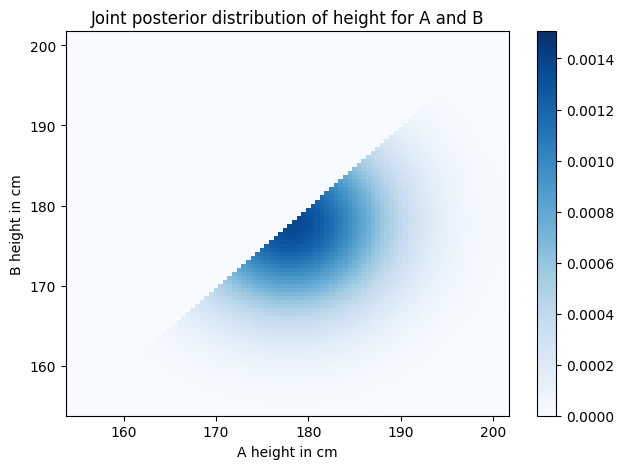

In [49]:
plot_joint(posterior)
decorate(title='Joint posterior distribution of height for A and B')

## Marginal Distributions

The joint posterior distribution represents what we believe about the height of A and B given the prior and likelihood. From this joint distribution, we can compute the posterior distributions for A and B. 

Suppose we want to know the probability that A is 180 cm tall. We can select the column from the joint distribution where x = 180. 

In [50]:
column = posterior[180]
column.head()

154.0    0.000010
154.5    0.000013
155.0    0.000015
155.5    0.000019
156.0    0.000022
Name: 180.0, dtype: float64

In [51]:
column.sum()

np.float64(0.03017221271570808)

So the is about a 3% chance that A is 180 cm. 

To get the posterior distributions of height for A, we can add up all of the columns:

In [53]:
column_sums = posterior.sum(axis = 0)
column_sums.head()

154.0    0.000000e+00
154.5    1.012260e-07
155.0    2.736152e-07
155.5    5.532519e-07
156.0    9.915650e-07
dtype: float64

This gives us a series that contains all possible heights for A and thier probabilities. 

In [54]:
marginal_A = Pmf(column_sums)

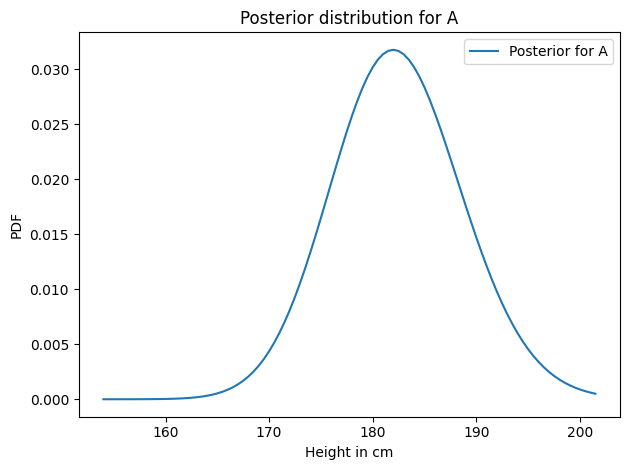

In [55]:
marginal_A.plot(label='Posterior for A')

decorate(xlabel='Height in cm',
         ylabel='PDF',
         title='Posterior distribution for A')

Similarly, we can get the posterior of height for B. 

In [56]:
row_sums = posterior.sum(axis = 1)
marginal_B = Pmf(row_sums)

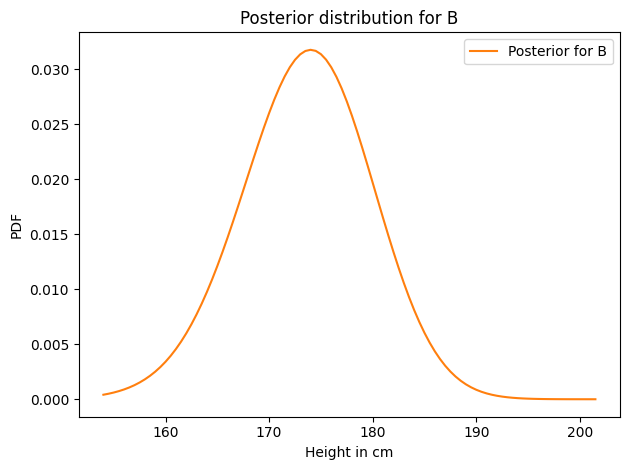

In [57]:
marginal_B.plot(label='Posterior for B', color='C1')

decorate(xlabel='Height in cm',
         ylabel='PDF',
         title='Posterior distribution for B')

In [58]:
# put this code in a function

def marginal(joint, axis):
    """ compute a marginal distribution"""
    return Pmf(joint.sum(axis = axis))

In [59]:
marginal_A = marginal(posterior, axis = 0)
marginal_B = marginal(posterior, axis = 1)

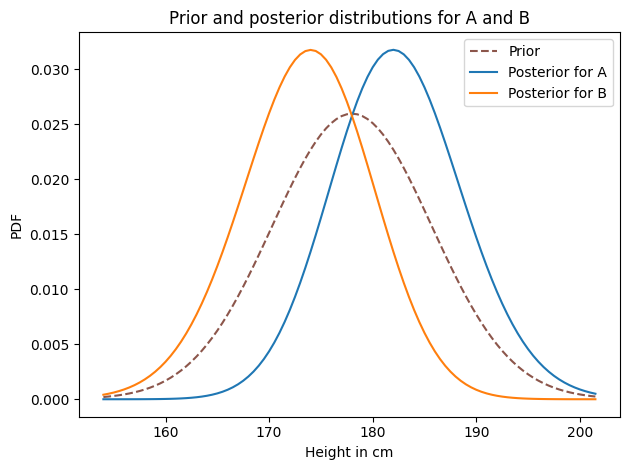

In [60]:
prior.plot(style='--', label='Prior', color='C5')
marginal_A.plot(label='Posterior for A')
marginal_B.plot(label='Posterior for B')

decorate(xlabel='Height in cm',
         ylabel='PDF',
         title='Prior and posterior distributions for A and B')

In [61]:
# summarize results

prior.mean()

np.float64(177.99516026921506)

In [62]:
print(marginal_A.mean(), marginal_B.mean())

182.38728123421686 173.6028600023339


In [63]:
prior.std()

np.float64(7.624924796641578)

In [64]:
print(marginal_A.std(), marginal_B.std())

6.27046117764547 6.280513548175111


## Conditional Posteriors

In [65]:
# If we measure A at 170 cm, what do we know about B?

column_170 = posterior[170]

cond_B = Pmf(column_170)
cond_B.normalize()

np.float64(0.004358061205454472)

Making a Pmf copies the data by default so we can normalize conb_B without affecting column_170 or posterior. 

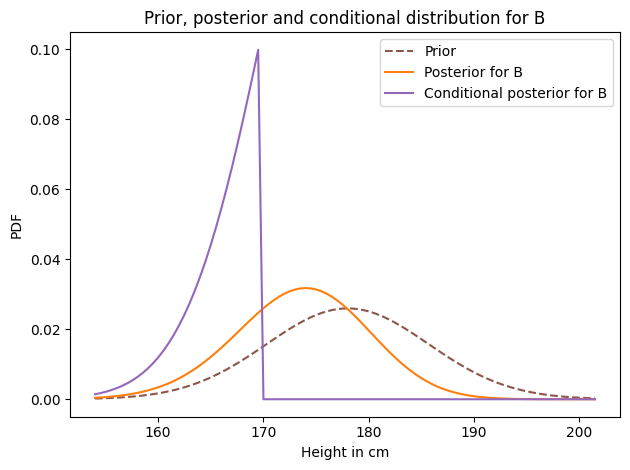

In [69]:
prior.plot(style='--', label='Prior', color='C5')
marginal_B.plot(label='Posterior for B', color='C1')
cond_B.plot(label='Conditional posterior for B', 
            color='C4')

decorate(xlabel='Height in cm',
         ylabel='PDF',
         title='Prior, posterior and conditional distribution for B')